# Customer Engagement & Product Utilization Analytics for Retention Strategy

**Author:** Iqra
**Program:** Unified Mentor — Data Analyst & Data Science Internship
**Dataset:** European Bank customer records (10,000 rows)

This notebook walks through the full analysis end-to-end: data validation, engagement
classification, product utilization analysis, financial-commitment vs. engagement
analysis, the Relationship Strength Index, statistical validation (chi-square tests,
correlations, confidence intervals), and a supplementary predictive model.

It mirrors the three standalone scripts in `analysis/` (`01_engagement_retention_analysis.py`,
`02_statistical_validation.py`, `03_predictive_model.py`) combined into one narrated notebook
for easy exploration and portfolio review.

## 1. Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Data Ingestion & Validation

Load the raw dataset and confirm it is clean: no missing values, no duplicate
customer IDs, and binary fields contain only 0/1.

In [24]:
df = pd.read_csv("../data/customer_engagement_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate CustomerIds:", df["CustomerId"].duplicated().sum())
print("HasCrCard unique values:", sorted(df["HasCrCard"].unique()))
print("IsActiveMember unique values:", sorted(df["IsActiveMember"].unique()))
print("Exited unique values:", sorted(df["Exited"].unique()))
print("Geography values:", sorted(df["Geography"].unique()))
print("NumOfProducts range:", df["NumOfProducts"].min(), "-", df["NumOfProducts"].max())

Missing values per column:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate CustomerIds: 0
HasCrCard unique values: [np.int64(0), np.int64(1)]
IsActiveMember unique values: [np.int64(0), np.int64(1)]
Exited unique values: [np.int64(0), np.int64(1)]
Geography values: ['France', 'Germany', 'Spain']
NumOfProducts range: 1 - 4


## 3. Engagement Classification

Each customer is assigned to one of four engagement profiles based on activity
status, product count, and balance relative to the 75th percentile:

- **Active Engaged** — active member holding 2+ products
- **Active Low-Product** — active member holding only 1 product
- **Inactive Disengaged** — inactive member, balance below the high-balance threshold
- **Inactive High-Balance** — inactive member, balance at/above the 75th percentile

In [26]:
median_balance = df["Balance"].median()
high_balance_threshold = df["Balance"].quantile(0.75)

def classify_engagement(row):
    active = row["IsActiveMember"] == 1
    multi_product = row["NumOfProducts"] >= 2
    high_balance = row["Balance"] >= high_balance_threshold
    if active and multi_product:
        return "Active Engaged"
    elif not active and high_balance:
        return "Inactive High-Balance"
    elif active and not multi_product:
        return "Active Low-Product"
    elif not active and not high_balance:
        return "Inactive Disengaged"
    return "Other"

df["EngagementProfile"] = df.apply(classify_engagement, axis=1)

engagement_summary = df.groupby("EngagementProfile").agg(
    Customers=("CustomerId", "count"),
    ChurnRate=("Exited", "mean"),
    AvgBalance=("Balance", "mean"),
    AvgProducts=("NumOfProducts", "mean"),
).round(3)
engagement_summary["ChurnRatePct"] = (engagement_summary["ChurnRate"] * 100).round(2)
engagement_summary.sort_values("ChurnRatePct", ascending=False)

,Customers,ChurnRate,AvgBalance,AvgProducts,ChurnRatePct
EngagementProfile,,,,,
Inactive High-Balance,1247,0.305,148857.680,1.382,30.5
Inactive Disengaged,3602,0.256,52304.016,1.574,25.6
Active Low-Product,2563,0.189,98902.019,1.000,18.9
Active Engaged,2588,0.097,53071.261,2.066,9.7


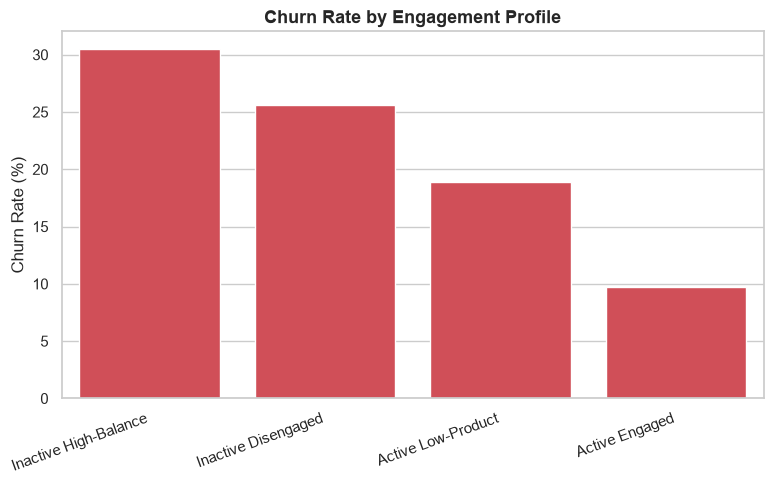

In [27]:
plt.figure(figsize=(8, 5))
order = engagement_summary.reset_index().sort_values("ChurnRatePct", ascending=False)
sns.barplot(data=order, x="EngagementProfile", y="ChurnRatePct", color="#E63946")
plt.title("Churn Rate by Engagement Profile", fontsize=13, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 4. Product Utilization Analysis

Churn rate by number of products held, and single-product vs. multi-product
comparison (the **Product Depth Index**).

In [28]:
product_churn = df.groupby("NumOfProducts").agg(
    Customers=("CustomerId", "count"),
    ChurnRate=("Exited", "mean"),
).round(3)
product_churn["ChurnRatePct"] = (product_churn["ChurnRate"] * 100).round(2)
product_churn

,Customers,ChurnRate,ChurnRatePct
NumOfProducts,,,
1,5084,0.277,27.7
2,4590,0.076,7.6
3,266,0.827,82.7
4,60,1.000,100.0


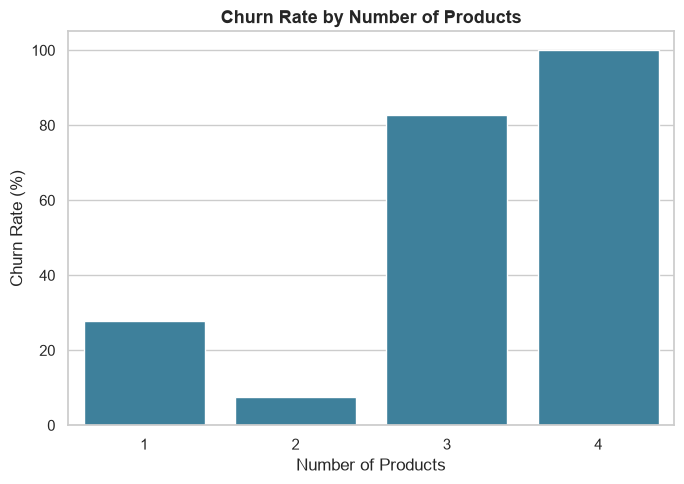

In [29]:
plt.figure(figsize=(7, 5))
sns.barplot(data=product_churn.reset_index(), x="NumOfProducts", y="ChurnRatePct", color="#2E86AB")
plt.title("Churn Rate by Number of Products", fontsize=13, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Number of Products")
plt.tight_layout()
plt.show()

In [30]:
df["ProductTier"] = np.where(df["NumOfProducts"] == 1, "Single-Product", "Multi-Product")
single_vs_multi = df.groupby("ProductTier").agg(
    Customers=("CustomerId", "count"), ChurnRate=("Exited", "mean")
).round(3)
single_vs_multi["ChurnRatePct"] = (single_vs_multi["ChurnRate"] * 100).round(2)

single_rate = single_vs_multi.loc["Single-Product", "ChurnRate"]
multi_rate = single_vs_multi.loc["Multi-Product", "ChurnRate"]
product_depth_index = round((single_rate - multi_rate) / single_rate * 100, 2)

print(single_vs_multi)
print(f"\nProduct Depth Index: {product_depth_index}% relative churn reduction (multi vs. single product)")

                Customers  ChurnRate  ChurnRatePct
ProductTier                                       
Multi-Product        4916      0.128          12.8
Single-Product       5084      0.277          27.7

Product Depth Index: 53.79% relative churn reduction (multi vs. single product)


## 5. Financial Commitment vs. Engagement Analysis

Balance is segmented into quartile tiers and cross-tabulated with activity
status, to test whether financial commitment alone predicts loyalty. We also
flag "at-risk premium" customers — Premium-balance customers who are inactive.

In [31]:
df["BalanceTier"] = pd.qcut(df["Balance"].rank(method="first"), 4,
                             labels=["Low", "Medium", "High", "Premium"])

balance_activity = df.groupby(["BalanceTier", "IsActiveMember"]).agg(
    Customers=("CustomerId", "count"), ChurnRate=("Exited", "mean")
).round(3)
balance_activity["ChurnRatePct"] = (balance_activity["ChurnRate"] * 100).round(2)
balance_activity

Customers  ChurnRate  ChurnRatePct
BalanceTier IsActiveMember                                    
Low         0                    1227      0.184          18.4
            1                    1273      0.110          11.0
Medium      0                    1166      0.242          24.2
            1                    1334      0.105          10.5
High        0                    1209      0.342          34.2
            1                    1291      0.188          18.8
Premium     0                    1247      0.305          30.5
            1                    1253      0.169          16.9

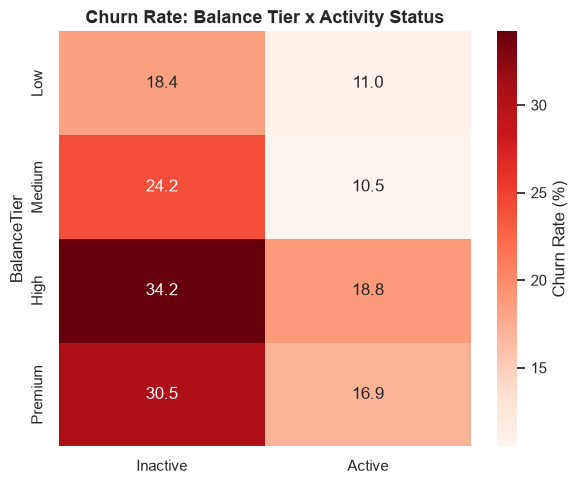

In [32]:
pivot = balance_activity["ChurnRatePct"].unstack()
pivot.columns = ["Inactive", "Active"]
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Churn Rate (%)"})
plt.title("Churn Rate: Balance Tier x Activity Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
at_risk_premium = df[(df["BalanceTier"] == "Premium") & (df["IsActiveMember"] == 0)]
print("At-risk premium customers:", len(at_risk_premium))
print(f"Their churn rate: {at_risk_premium['Exited'].mean()*100:.2f}%")

At-risk premium customers: 1247
Their churn rate: 30.47%


## 6. Retention Strength Assessment — the Relationship Strength Index (RSI)

A composite 0–10 score combining four behavioral signals:

$$RSI = 2 \times (\text{Active Member}) + 1.5 \times (\text{Products, capped at 4}) + 1 \times (\text{Has Credit Card}) + 1 \times (\text{Tenure} \geq 5)$$

Score ≥ 6 → **Sticky**, Score < 6 → **At-Risk**. Weights are set by reasoned
judgment (active status and product depth weighted heaviest), not data-fit —
Section 9 of this notebook checks that against a data-fit model.

In [34]:
def relationship_strength_score(row):
    score = 0
    score += 2 if row["IsActiveMember"] == 1 else 0
    score += min(row["NumOfProducts"], 4) * 1.5
    score += 1 if row["HasCrCard"] == 1 else 0
    score += 1 if row["Tenure"] >= 5 else 0
    return round(score, 2)

df["RelationshipStrengthIndex"] = df.apply(relationship_strength_score, axis=1)
df["StickyCustomer"] = np.where(df["RelationshipStrengthIndex"] >= 6, "Sticky", "At-Risk")

df["RSIBucket"] = pd.cut(df["RelationshipStrengthIndex"], bins=[-1, 2, 4, 6, 8, 100],
                          labels=["0-2", "2-4", "4-6", "6-8", "8+"])
rsi_bucket_churn = df.groupby("RSIBucket").agg(
    Customers=("CustomerId", "count"), ChurnRate=("Exited", "mean")
).round(3)
rsi_bucket_churn["ChurnRatePct"] = (rsi_bucket_churn["ChurnRate"] * 100).round(2)
rsi_bucket_churn

,Customers,ChurnRate,ChurnRatePct
RSIBucket,,,
0-2,323,0.331,33.1
2-4,3858,0.269,26.9
4-6,4631,0.140,14.0
6-8,1121,0.167,16.7
8+,67,0.851,85.1


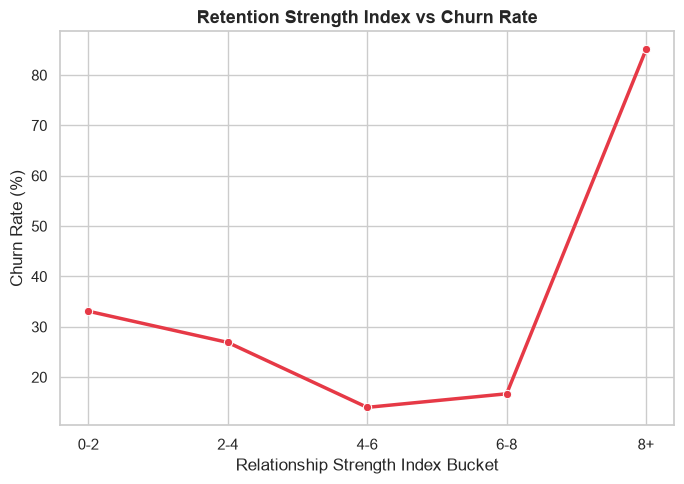

In [35]:
plt.figure(figsize=(7, 5))
sns.lineplot(data=rsi_bucket_churn.reset_index(), x="RSIBucket", y="ChurnRatePct",
             marker="o", color="#E63946", linewidth=2.5)
plt.title("Retention Strength Index vs Churn Rate", fontsize=13, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Relationship Strength Index Bucket")
plt.tight_layout()
plt.show()

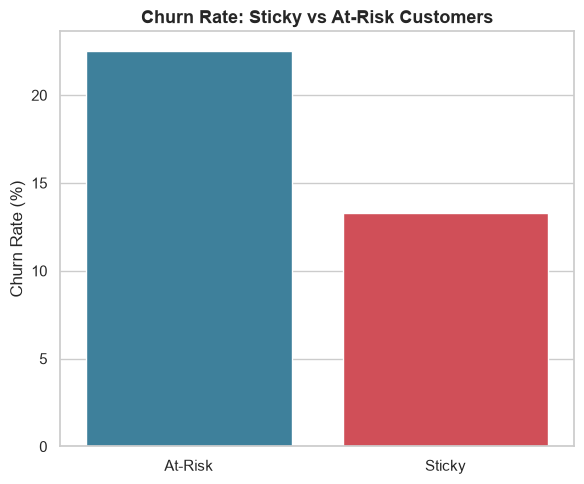

,Customers,ChurnRate,ChurnRatePct
StickyCustomer,,,
At-Risk,7668,0.225,22.5
Sticky,2332,0.133,13.3


In [36]:
sticky_summary = df.groupby("StickyCustomer").agg(
    Customers=("CustomerId", "count"), ChurnRate=("Exited", "mean")
).round(3)
sticky_summary["ChurnRatePct"] = (sticky_summary["ChurnRate"] * 100).round(2)

plt.figure(figsize=(6, 5))
sns.barplot(data=sticky_summary.reset_index(), x="StickyCustomer", y="ChurnRatePct",
            hue="StickyCustomer", palette=["#2E86AB", "#E63946"], legend=False)
plt.title("Churn Rate: Sticky vs At-Risk Customers", fontsize=13, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()
sticky_summary

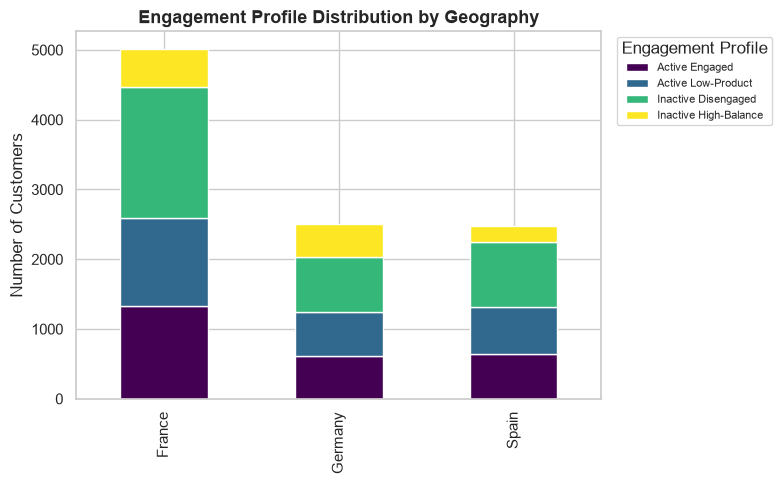

In [37]:
geo_engagement = df.groupby(["Geography", "EngagementProfile"]).size().reset_index(name="Count")
geo_pivot = geo_engagement.pivot(index="Geography", columns="EngagementProfile", values="Count").fillna(0)
geo_pivot.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="viridis")
plt.title("Engagement Profile Distribution by Geography", fontsize=13, fontweight="bold")
plt.ylabel("Number of Customers")
plt.xlabel("")
plt.legend(title="Engagement Profile", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Key Performance Indicators

Summarizing the analysis above into the 5 KPIs the project requires.

In [38]:
active_churn = df[df["IsActiveMember"] == 1]["Exited"].mean()
inactive_churn = df[df["IsActiveMember"] == 0]["Exited"].mean()
engagement_retention_ratio = round(inactive_churn / active_churn, 2)

churn_1_product = df[df["NumOfProducts"] == 1]["Exited"].mean()
churn_multi_product = df[df["NumOfProducts"] >= 2]["Exited"].mean()
product_depth_index = round((churn_1_product - churn_multi_product) / churn_1_product * 100, 2)

high_balance_disengagement_rate = round(
    df[(df["BalanceTier"] == "Premium") & (df["IsActiveMember"] == 0)].shape[0]
    / df[df["BalanceTier"] == "Premium"].shape[0] * 100, 2
)

cc_churn = df[df["HasCrCard"] == 1]["Exited"].mean()
no_cc_churn = df[df["HasCrCard"] == 0]["Exited"].mean()
credit_card_stickiness_score = round((no_cc_churn - cc_churn) / no_cc_churn * 100, 2)

kpi_summary = {
    "Engagement Retention Ratio": f"{engagement_retention_ratio}x",
    "Product Depth Index": f"{product_depth_index}%",
    "High-Balance Disengagement Rate": f"{high_balance_disengagement_rate}%",
    "Credit Card Stickiness Score": f"{credit_card_stickiness_score}%",
    "Average Relationship Strength Index": f"{df['RelationshipStrengthIndex'].mean():.2f} / 10",
    "Overall Churn Rate": f"{df['Exited'].mean()*100:.2f}%",
}
for k, v in kpi_summary.items():
    print(f"{k}: {v}")

Engagement Retention Ratio: 1.88x
Product Depth Index: 53.91%
High-Balance Disengagement Rate: 49.88%
Credit Card Stickiness Score: 3.03%
Average Relationship Strength Index: 4.58 / 10
Overall Churn Rate: 20.37%


## 8. Statistical Validation

Every categorical relationship above is tested with a **chi-square test of
independence** against churn, and numeric features are ranked by
**point-biserial correlation** with churn. This confirms the patterns are
statistically robust, not sampling artifacts.

In [39]:
def chi_square_test(df, col, target="Exited"):
    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    return {"variable": col, "chi2": round(chi2, 2), "df": dof, "p_value": p, "significant": p < 0.05}

for col in ["EngagementProfile", "ProductTier", "Geography", "StickyCustomer", "BalanceTier"]:
    result = chi_square_test(df, col)
    print(f"{result['variable']:22s} chi2={result['chi2']:>8.2f}  df={result['df']}  "
          f"p={'< 0.001' if result['p_value'] < 0.001 else round(result['p_value'], 4)}  "
          f"significant={result['significant']}")

EngagementProfile      chi2=  325.46  df=3  p=< 0.001  significant=True
ProductTier            chi2=  342.98  df=1  p=< 0.001  significant=True
Geography              chi2=  301.26  df=2  p=< 0.001  significant=True
StickyCustomer         chi2=   93.33  df=1  p=< 0.001  significant=True
BalanceTier            chi2=  140.10  df=3  p=< 0.001  significant=True


In [40]:
numeric_features = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                     "EstimatedSalary", "RelationshipStrengthIndex"]
correlations = []
for feat in numeric_features:
    r, p = pointbiserialr(df["Exited"], df[feat])
    correlations.append({"feature": feat, "r": round(r, 3), "p_value": p})

corr_df = pd.DataFrame(correlations).sort_values("r", key=abs, ascending=False)
corr_df

,feature,r,p_value
1,Age,0.285,1.239931e-186
6,RelationshipStrengthIndex,-0.140,7.106095e-45
3,Balance,0.119,1.275563e-32
4,NumOfProducts,-0.048,1.717333e-06
0,CreditScore,-0.027,6.738214e-03
2,Tenure,-0.014,1.615268e-01
5,EstimatedSalary,0.012,2.264404e-01


In [41]:
def churn_rate_ci(subset):
    n = len(subset)
    p_hat = subset["Exited"].mean()
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat, p_hat - 1.96 * se, p_hat + 1.96 * se

active = df[df["IsActiveMember"] == 1]
inactive = df[df["IsActiveMember"] == 0]
a_rate, a_lo, a_hi = churn_rate_ci(active)
i_rate, i_lo, i_hi = churn_rate_ci(inactive)

print(f"Active churn rate:   {a_rate*100:.2f}%  (95% CI: [{a_lo*100:.2f}%, {a_hi*100:.2f}%])")
print(f"Inactive churn rate: {i_rate*100:.2f}%  (95% CI: [{i_lo*100:.2f}%, {i_hi*100:.2f}%])")
print("\nNon-overlapping CIs confirm this gap is real, not sampling noise.")

Active churn rate:   14.27%  (95% CI: [13.31%, 15.22%])
Inactive churn rate: 26.85%  (95% CI: [25.60%, 28.10%])

Non-overlapping CIs confirm this gap is real, not sampling noise.


## 9. Predictive Modeling (Supplementary)

A logistic regression baseline, trained on a 75/25 stratified split, to test
whether churn is predictable at the individual level and to isolate each
feature's independent effect.

**Honest framing:** this is a simple interpretable baseline, not a tuned
production model — the goal is to test relationships, not maximize accuracy.

In [42]:
model_df = df.copy()
model_df["Germany"] = (model_df["Geography"] == "Germany").astype(int)
model_df["Spain"] = (model_df["Geography"] == "Spain").astype(int)
model_df["Gender_Male"] = (model_df["Gender"] == "Male").astype(int)

feature_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                 "HasCrCard", "IsActiveMember", "EstimatedSalary",
                 "Germany", "Spain", "Gender_Male"]
X = model_df[feature_cols]
y = model_df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Baseline (predict majority class): {1 - y_test.mean():.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy:  0.8092
Baseline (predict majority class): 0.7964
Precision: 0.5988
Recall:    0.1906
F1-score:  0.2891
ROC-AUC:   0.7836


In [43]:
print("""The model's accuracy is only marginally better than the naive baseline, and its
recall on actual churners is low. This is an honest, useful negative result: a
simple linear model cannot reliably flag individual churners from these features
alone. It reinforces this project's central argument -- the engagement-profile
segmentation above achieves much clearer separation than this model's
individual-level predictions, because it captures the same signal through
interpretable, non-linear business rules rather than a single linear score.""")

The model's accuracy is only marginally better than the naive baseline, and its
recall on actual churners is low. This is an honest, useful negative result: a
simple linear model cannot reliably flag individual churners from these features
alone. It reinforces this project's central argument -- the engagement-profile
segmentation above achieves much clearer separation than this model's
individual-level predictions, because it captures the same signal through
interpretable, non-linear business rules rather than a single linear score.


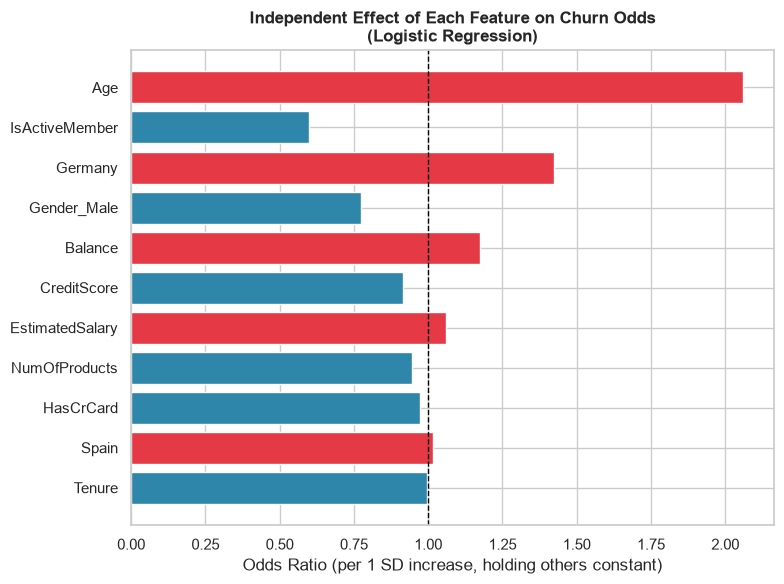

,feature,coefficient,odds_ratio
1,Age,0.7232,2.061
6,IsActiveMember,-0.5118,0.599
8,Germany,0.3519,1.422
10,Gender_Male,-0.2565,0.774
3,Balance,0.1605,1.174
0,CreditScore,-0.0889,0.915
7,EstimatedSalary,0.0576,1.059
4,NumOfProducts,-0.0567,0.945
5,HasCrCard,-0.0287,0.972
9,Spain,0.0152,1.015


In [44]:
odds_ratios = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0].round(4),
    "odds_ratio": np.exp(model.coef_[0]).round(3),
}).sort_values("coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 6))
colors = ["#E63946" if v > 1 else "#2E86AB" for v in odds_ratios["odds_ratio"]]
plt.barh(odds_ratios["feature"], odds_ratios["odds_ratio"], color=colors)
plt.axvline(x=1, color="black", linewidth=1, linestyle="--")
plt.xlabel("Odds Ratio (per 1 SD increase, holding others constant)")
plt.title("Independent Effect of Each Feature on Churn Odds\n(Logistic Regression)",
           fontsize=12, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

odds_ratios

## 10. Conclusion

Engagement — measured through activity status, product depth, and tenure — is
a stronger predictor of retention than balance or salary, and this holds up
under statistical testing (chi-square tests, correlation analysis, confidence
intervals) and even under a supplementary predictive model that itself confirms
rule-based segmentation is more actionable than a single linear churn score.

**See the companion Research Paper (`docs/`) for full methodology, statistical
detail, and business recommendations, and the Streamlit dashboard (`app/`) for
an interactive version of this analysis.**